**K.V. Kozenko, V.V.Gromyko, I.I. Beterov, I.I.Ryabtsev. Monte-Carlo simulation of performance of amplitude-robust CZ gate at finite temperature of atoms. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def Rabi(r: float, z: float, lam: float, w0=1e-6):
    z0=np.pi*w0**2/lam
    return np.exp(-r**2/(w0**2))*np.exp(-z**2/(2*(z0**2)))

In [3]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateAsym:

    def __init__(self,    Vnn: float,  s1=1,  s2=1):
        self._s1 = s1
        self._s2 = s2
        self._Vnn = Vnn 
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s1=self._s1
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s1],
                   [Omega* jnp.exp(1j * Xi)*0.5*s1,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s2=self._s2
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s2],
                   [Omega* jnp.exp(1j * Xi)*s2*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            V=self._Vnn
            s1=self._s1
            s2=self._s2
            return jnp.array(
                    [
                      [0, Omega*jnp.exp(-1j * Xi)*0.5*s1, Omega*jnp.exp(-1j * Xi)*0.5*s2, 0], 
                      [Omega*jnp.exp(1j * Xi)*0.5*s1, Delta, 0, Omega* jnp.exp(-1j * Xi)*0.5*s2], 
                      [Omega* jnp.exp(1j * Xi)*0.5*s2, 0,  Delta, Omega* jnp.exp(-1j * Xi)*0.5*s1], 
                      [0, Omega* jnp.exp(1j * Xi)*0.5*s2, Omega*jnp.exp(1j * Xi)*0.5*s1, 2.0*Delta + V]
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Single-photon excitation**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
d=19.16385937372734
initial_params =  (1, [-0.37987234*d ], [0.4383259*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdepS=[]
datasize=100

for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))
    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(297e-9))/10
    Scaling1=Rabi(Radial1,Axial1,297e-9)
    Scaling2=Rabi(Radial2,Axial2,297e-9)
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(Scaling1)):
        gate = CZGateAsym(10000,s1=Scaling1[i] ,s2=Scaling2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdepS.append(np.mean(FRobustT).item())
RobustTdepS

In [13]:
RobustTdepS

[2.397751829433914e-05,
 7.575773767640293e-05,
 0.0001259576325006484,
 0.0002126555983069822,
 0.0002856755364489139,
 0.00039172072712722494]

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
 
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdepS=[]
datasize=100

for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))
    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(297e-9))/10
    Scaling1=Rabi(Radial1,Axial1,297e-9)
    Scaling2=Rabi(Radial2,Axial2,297e-9)
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(Scaling1)):
        gate = CZGateAsym(10000,s1=Scaling1[i] ,s2=Scaling2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdepS.append(np.mean(FRobustT).item())
FTOTdepS

In [12]:
FTOTdepS

[8.852658231116362e-05,
 0.0006049656822245364,
 0.0017952772957673347,
 0.0027417274237891897,
 0.004392577803013712,
 0.006666501091781847]

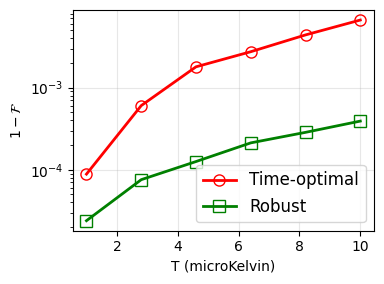

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdepS, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdepS, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarloSinglePhoton.svg', format='svg')
# Display the plot
plt.show()

**Now we analayze robustness of two-photon scheme to asymmetry**

In [3]:
from sympy import symbols, Matrix 
import sympy as sp
import numpy as np
from sympy.physics.quantum import TensorProduct
Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR= symbols('Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR')
Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2 = symbols('Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2  ')
Drive1 = Matrix( [
                   [0,Omega1P*0.5,0],
                   [Omega1PC*0.5,-Delta1P-1j*0.5*DecayP,Omega1S*0.5],
                   [0,Omega1SC*0.5,Delta1-1j*0.5*DecayR]
                                                          
                ])
Drive2 = Matrix( [
                   [0,Omega2P*0.5,0],
                   [Omega2PC*0.5,-Delta2P-1j*0.5*DecayP,Omega2S*0.5],
                   [0,Omega2SC*0.5,Delta2-1j*0.5*DecayR]
                                                          
                ])

In [23]:
Drive1

Matrix([
[           0,             0.5*Omega1P,                      0],
[0.5*Omega1PC, -0.5*I*DecayP - Delta1P,            0.5*Omega1S],
[           0,            0.5*Omega1SC, -0.5*I*DecayR + Delta1]])

In [27]:
Drive2

Matrix([
[           0,             0.5*Omega2P,                      0],
[0.5*Omega2PC, -0.5*I*DecayP - Delta2P,            0.5*Omega2S],
[           0,            0.5*Omega2SC, -0.5*I*DecayR + Delta2]])

In [24]:
Identity3= Matrix(np.eye(3))
expr=TensorProduct(Drive2, Identity3)+TensorProduct(Identity3, Drive1)
expr

Matrix([
[           0,                 0.5*Omega1P,                          0,                 0.5*Omega2P,                                         0,                                                       0,                          0,                                                       0,                                       0],
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P,                0.5*Omega1S,                           0,                               0.5*Omega2P,                                                       0,                          0,                                                       0,                                       0],
[           0,                0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1,                           0,                                         0,                                             0.5*Omega2P,                          0,                                                       0,                                       0],
[0.5*Om

In [29]:
for i in range(expr.rows):
    print(list(expr.row(i)))

[0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0]
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0]
[0, 0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0]
[0.5*Omega2PC, 0, 0, -0.5*I*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0]
[0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*I*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0]
[0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*I*DecayP - 0.5*I*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S]
[0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*I*DecayR + 1.0*Delta2, 0.5*Omega1P, 0]
[0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*I*DecayP - 0.5*I*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S]
[0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*I*DecayR + 1.0*Delta1 + 1.0*Delta2]


In [25]:
print(Drive1)

Matrix([[0, 0.5*Omega1P, 0], [0.5*Omega1PC, -0.5*I*DecayP - Delta1P, 0.5*Omega1S], [0, 0.5*Omega1SC, -0.5*I*DecayR + Delta1]])


**Asymmetric two-photon gate with finite blockade strength**

In [3]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonAsymm:

    def __init__(self, Vnn: float, Delta1P: float,  Delta2P :float,  DecayP=0, DecayR=0, s1=1, s2=1, p1=1, p2=1):
        self._Delta1P = Delta1P
        self._Delta2P = Delta2P
        self._DecayP = DecayP
        self._DecayR = DecayR
        self._Vnn = Vnn
        self._s1=s1
        self._s2=s2
        self._p1=p1
        self._p2=p2
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta1=Delta
            Delta1P=self._Delta1P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s1=self._s1
            p1=self._p1
            
            Omega1S=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(+1j*Xi)*s1
            
            Omega1P=jnp.sqrt(2*Delta1P*Omega)*p1
            Omega1PC=jnp.sqrt(2*Delta1P*Omega)*p1
            
              
            return jnp.array(
            [
                    [0, 0.5*Omega1P, 0], 
                    [0.5*Omega1PC, -0.5*1j*DecayP - Delta1P, 0.5*Omega1S], 
                    [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1]                                    
                ]
            )

        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta2=Delta
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s2=self._s2
            p2=self._p2
            
        
            Omega2S=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(-1j * Xi)*s2
            Omega2SC=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(1j * Xi)*s2
            
            Omega2P=jnp.sqrt(2*Delta2P*Omega)*p2
            Omega2PC=jnp.sqrt(2*Delta2P*Omega)*p2
            return jnp.array(
                [
                    [0, 0.5*Omega2P, 0], 
                    [0.5*Omega2PC, -0.5*1j*DecayP - Delta2P, 0.5*Omega2S], 
                    [0, 0.5*Omega2SC, -0.5*1j*DecayR + Delta2]                                    
                ]                                           
                
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re,rr"""
            Delta1=Delta
            Delta2=Delta
            Delta1P=self._Delta1P
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            Vnn=self._Vnn
            s1=self._s1
            p1=self._p1
            s2=self._s2
            p2=self._p2
            
            Omega1S=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(1j* Xi)*s1
            
            Omega1P=jnp.sqrt(2*Delta1P*Omega)*p1
            Omega1PC=jnp.sqrt(2*Delta1P*Omega)*p1
            
            Omega2S=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(-1j * Xi )*s2
            Omega2SC=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(1j * Xi )*s2
            
            Omega2P=jnp.sqrt(2*Delta2P*Omega)*p2
            Omega2PC=jnp.sqrt(2*Delta2P*Omega)*p2
            
            return jnp.array([
                [0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0],
                [0.5*Omega1PC, -0.5*1j*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0],
                [0, 0.5*Omega1SC, -0.5*1j*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0],
                [0.5*Omega2PC, 0, 0, -0.5*1j*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0],
                [0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*1j*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0],
                [0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*1j*DecayP - 0.5*1j*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S],
                [0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*1j*DecayR + 1.0*Delta2, 0.5*Omega1P, 0],
                [0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*1j*DecayP - 0.5*1j*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S],
                [0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*1j*DecayR + 1.0*Delta1 + 1.0*Delta2+Vnn]       
            ]

              
            )
        return hamiltonian1, hamiltonian2,hamiltonian3
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p1 = jnp.angle(obtained_gate[1]) 
        p2 = jnp.angle(obtained_gate[2]) 
        t = np.pi
        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p1),
                jnp.exp(1j * p2),
                jnp.exp(1j * ( p1+p2 + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Asymmetric smooth robust gate**

In [5]:
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
gate = CZGateTwoPhotonAsymm(10000,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.05,p1=1 ,p2=1.05)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.00024341587439513646

**Asymmetric const robust gate**

In [6]:
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
d=19.16385937372734
const_end_new_metrics_params =  (1, [-0.37987234*d ], [0.4383259*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
gate = CZGateTwoPhotonAsymm(10000,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.05,p1=1  ,p2=1.05)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const, const_end_new_metrics_params )
1-gate.process_fidelity(time_evolved_basis_states).item()

0.005526209590810183

**Asymmetric smooth time-optimal gate**

In [6]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
gate = CZGateTwoPhotonAsymm(10000,2*np.pi*500,2*np.pi*500,s1=1.  ,s2=1.05,p1=1.0 ,p2=1.05 )
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.010526718099114873

**Asymmetric constant Rabi frequency robust gate**

In [7]:
d=19.16385937372734
pulse_ansatz  = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, 
    phase_ansatz=ro.pulses.lin_sin_cos_crab, 
    rabi_ansatz=ro.pulses.const)
optimized_params  =  (d, [-0.37987234 ], [0.43832597, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583])
gate = CZGateTwoPhotonAsymm(500,2*np.pi*500,2*np.pi*500,s1=1.04 ,s2=0.97,p1=1.03 ,p2=0.98 )
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, optimized_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0008733966907225055

**Monte-Carlo simulation for two-photon excitation at 480 nm and 780 nm with Doppler**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
 

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdep480D=[]
datasize=200 
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdep480D.append(np.mean(FRobustT).item())
RobustTdep480D

In [7]:
RobustTdep480D

[0.00010694307701632932,
 0.00041066914564848845,
 0.001323433564463074,
 0.002618044501564407,
 0.006463988968455149,
 0.008063151241631084]

In [6]:
RobustTdep480D=[0.00010694307701632932,
 0.00041066914564848845,
 0.001323433564463074,
 0.002618044501564407,
 0.006463988968455149,
 0.008063151241631084]

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep480D=[]
datasize=200 
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdep480D.append(np.mean(FRobustT).item())
FTOTdep480D

In [4]:
FTOTdep480D=[0.0003480558861278671,
 0.002643267422782853,
 0.006134916613201138,
 0.014654973388675462,
 0.018592121781869513,
 0.027020827060393167]

In [5]:
FTOTdep480D

[0.0003480558861278671,
 0.002643267422782853,
 0.006134916613201138,
 0.014654973388675462,
 0.018592121781869513,
 0.027020827060393167]

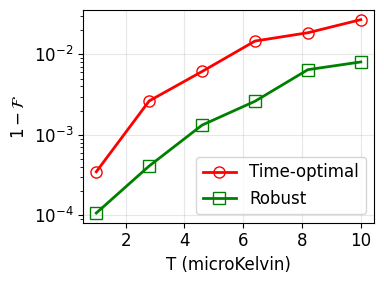

In [9]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep480D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep480D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo480D.svg', format='svg')
# Display the plot
plt.show()

**Monte-Carlo simulation for two-photon Rydberg excitation at 420 nm and 1013 nm with Doppler**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
 

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdep420D=[]
datasize=200 
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,420e-9)
    ScalingS1=Rabi(Radial1,Axial1,1013e-9)
    ScalingP2=Rabi(Radial2,Axial2,420e-9)
    ScalingS2=Rabi(Radial2,Axial2,1013e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*500,2*np.pi*500,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdep420D.append(np.mean(FRobustT).item())
RobustTdep420D

In [10]:
RobustTdep420D=[0.0008061703278496601,
 0.003414170919280811,
 0.008351351374010886,
 0.013525918468707465,
 0.018382912361388174,
 0.03921793640988738]

In [16]:
RobustTdep420D

[0.0008061703278496601,
 0.003414170919280811,
 0.008351351374010886,
 0.013525918468707465,
 0.018382912361388174,
 0.03921793640988738]

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep420D=[]
datasize=200 
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,420e-9)
    ScalingS1=Rabi(Radial1,Axial1,1013e-9)
    ScalingP2=Rabi(Radial2,Axial2,420e-9)
    ScalingS2=Rabi(Radial2,Axial2,1013e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdep420D.append(np.mean(FRobustT).item())
FTOTdep420D

In [14]:
FTOTdep420D

[0.000679175336557598,
 0.004544621012128899,
 0.013671009608614709,
 0.021861107131232974,
 0.0342237977421548,
 0.04308087139654673]

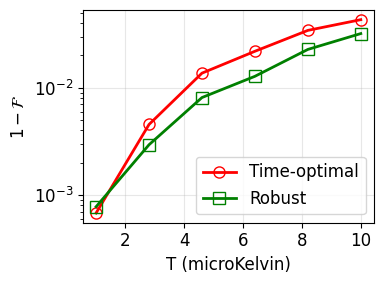

In [19]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep420D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep420D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo420D.svg', format='svg')
# Display the plot
plt.show()

**Monte-Carlo simulation for 480 nm and 780 nm depending on trap intensity**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  

d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
 

Ulist=np.linspace(5e-5,5e-4,6)

rng = np.random.default_rng()
RobustUdep480D=[]
datasize=200 
for j in range(len(Ulist)):
    U0=Ulist[j]
    T=5e-6
    wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
    wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustUdep480D.append(np.mean(FRobustT).item())
RobustUdep480D

In [5]:
RobustUdep480D

[0.008051346343516312,
 0.0008927110783233689,
 0.0003205348998838864,
 0.0001905520175262665,
 0.00013841939188831033,
 9.446530969770716e-05]

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  

pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])
 

Ulist=np.linspace(5e-5,5e-4,6)



rng = np.random.default_rng()
TOTUdep480D=[]
datasize=200 
for j in range(len(Ulist)):
    U0=Ulist[j]
    T=5e-6
    wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
    wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    TOTUdep480D.append(np.mean(FRobustT).item())
TOTUdep480D

In [8]:
TOTUdep480D

[0.031029298755259126,
 0.004086773618324191,
 0.001794038979241755,
 0.0008620390310404957,
 0.0005340955738485192,
 0.00039840550637513795]

**Dependence on trap intensity**

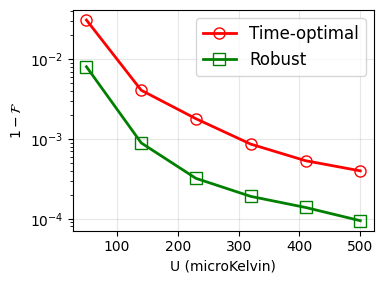

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Ulist*1e6, TOTUdep480D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Ulist*1e6, RobustUdep480D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("U (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarloU480.svg', format='svg')
# Display the plot
plt.show()

**Cesium two-photon excitation**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
 

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdep459D=[]
datasize=100
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,459e-9,w0=2e-6)
    ScalingS1=Rabi(Radial1,Axial1,1040e-9,w0=2-6)
    ScalingP2=Rabi(Radial2,Axial2,459e-9,w0=2e-6)
    ScalingS2=Rabi(Radial2,Axial2,1040e-9,w0=2e-6)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(459e-9)-1/(1040e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdep459D.append(np.mean(FRobustT).item())
RobustTdep459D

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])
 


Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
TOTdep459D=[]
datasize=100 
for j in range(len(Tlist)):
    T=Tlist[j]
    sigmaR=np.sqrt(kB*T/(MRb*wr**2))
    sigmaZ=np.sqrt(kB*T/(MRb*wz**2))
    sigmaV=np.sqrt(kB*T/(MRb))

    Radial1 = rng.normal(0, sigmaR, size=datasize )
    Axial1 = rng.normal(0, sigmaZ, size=datasize)
    Radial2 = rng.normal(0, sigmaR, size=datasize )
    Axial2 = rng.normal(0, sigmaZ, size=datasize)
    ScalingP1=Rabi(Radial1,Axial1,459e-9,w0=2e-6)
    ScalingS1=Rabi(Radial1,Axial1,1040e-9,w0=2-6)
    ScalingP2=Rabi(Radial2,Axial2,459e-9,w0=2e-6)
    ScalingS2=Rabi(Radial2,Axial2,1040e-9,w0=2e-6)
    Vz= rng.normal(0, sigmaV, size=datasize)
    Doppler=Vz*1e-6*2*np.pi*(1/(459e-9)-1/(1040e-9)) 
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(10000,2*np.pi*500,2*np.pi*500,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i])
        pulse_params  = initial_params[0],initial_params[1]+Doppler[i],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    TOTdep459D.append(np.mean(FRobustT).item())
TOTdep459D

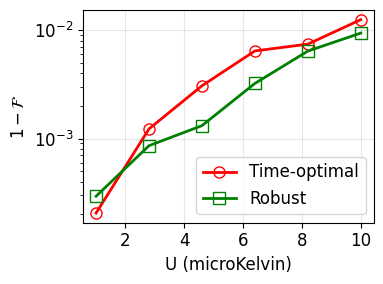

In [24]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, TOTdep459D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep459D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("U (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
#plt.savefig('RobustnessMonteCarloU459.svg', format='svg')
# Display the plot
plt.show()